In [1]:
import sys
sys.path.append("../")

from notebooks import *

In [20]:
import warnings
warnings.filterwarnings('ignore')

In [21]:
train_df= pd.read_csv("../data/processed/train_clean.csv")
test_df= pd.read_csv("../data/processed/test_clean.csv")

In [22]:
# set seaborn plotting style
# apply base theme
sns.set_style('darkgrid')

# customize plot appearance
sns.set(rc={
    "axes.facecolor": "#cce0ff",
    "figure.facecolor": "#cce0ff",
    "grid.color": "#D3D3D3",
    "text.color": "#000000",
    "font.size": 12,
    "axes.titlesize": 16
})

# set plotting context (controls scaling of labels, fonts, etc.)
sns.set_context("notebook")

# Check Point 2 - EDA

## Dataframe

In [23]:
train_df.head()

,Age,Income,Home_ownership,Employment_length,Loan_intent,internal_credit_rating,Loan_amount,Interest_rate,Loan_percent_income,Default,Credit_history_length,Loan_status
0,23.0,75800.0,Rent,0.0,Personal,A,7000.0,6.54,0.09,N,2.0,False
1,25.0,61959.0,Rent,9.0,Education,C,25000.0,12.73,0.40,Y,4.0,True
2,31.0,53088.0,Rent,0.0,Personal,A,6000.0,6.54,0.11,N,9.0,False
3,27.0,228000.0,Mortgage,12.0,Homeimprovement,A,6000.0,7.14,0.03,N,6.0,False
4,29.0,54000.0,Rent,0.0,Personal,D,10000.0,14.96,0.19,N,9.0,True


## Univariate Analysis

#### Customer's Income Distribution using histplot

Let's have a look on the distribution of customer's income:


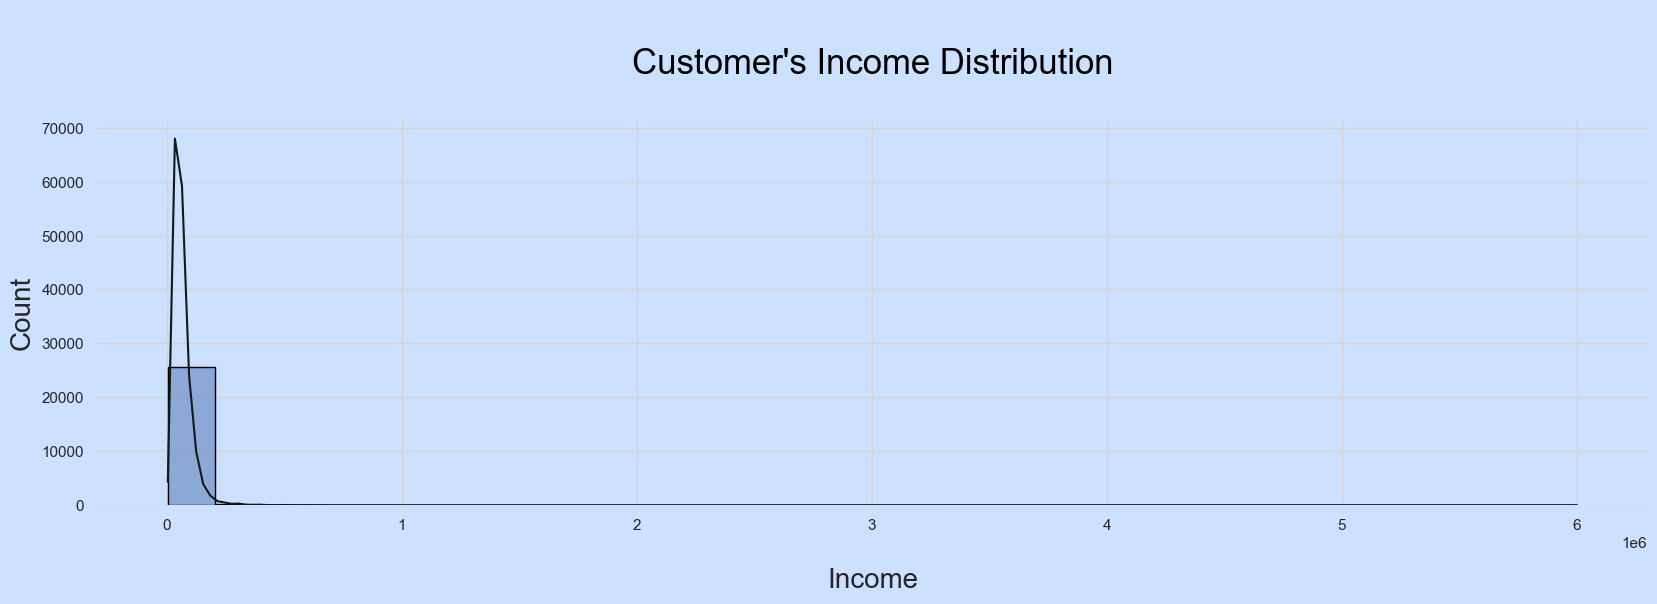

In [24]:
# plot distribution of customer's income
print("Let's have a look on the distribution of customer's income:")

plt.subplots(figsize=(20, 5))

p = sns.histplot(
    x='Income',
    kde=True,
    bins=30,
    fill=True,
    edgecolor='black',
    palette="Set2",
    data=train_df
)

# customize KDE line color
p.axes.lines[0].set_color('#101B15')

# set plot scale
p.axes.set_yscale('linear')

# set title
p.axes.set_title("\nCustomer's Income Distribution\n", fontsize=25)

# axis labels
plt.ylabel("Count", fontsize=20)
plt.xlabel("\nIncome", fontsize=20)

# remove unnecessary borders
sns.despine(left=True, bottom=True)

plt.show()

#### Customer's Age distribution histplot

Let's have a look on the distribution of customer's age:


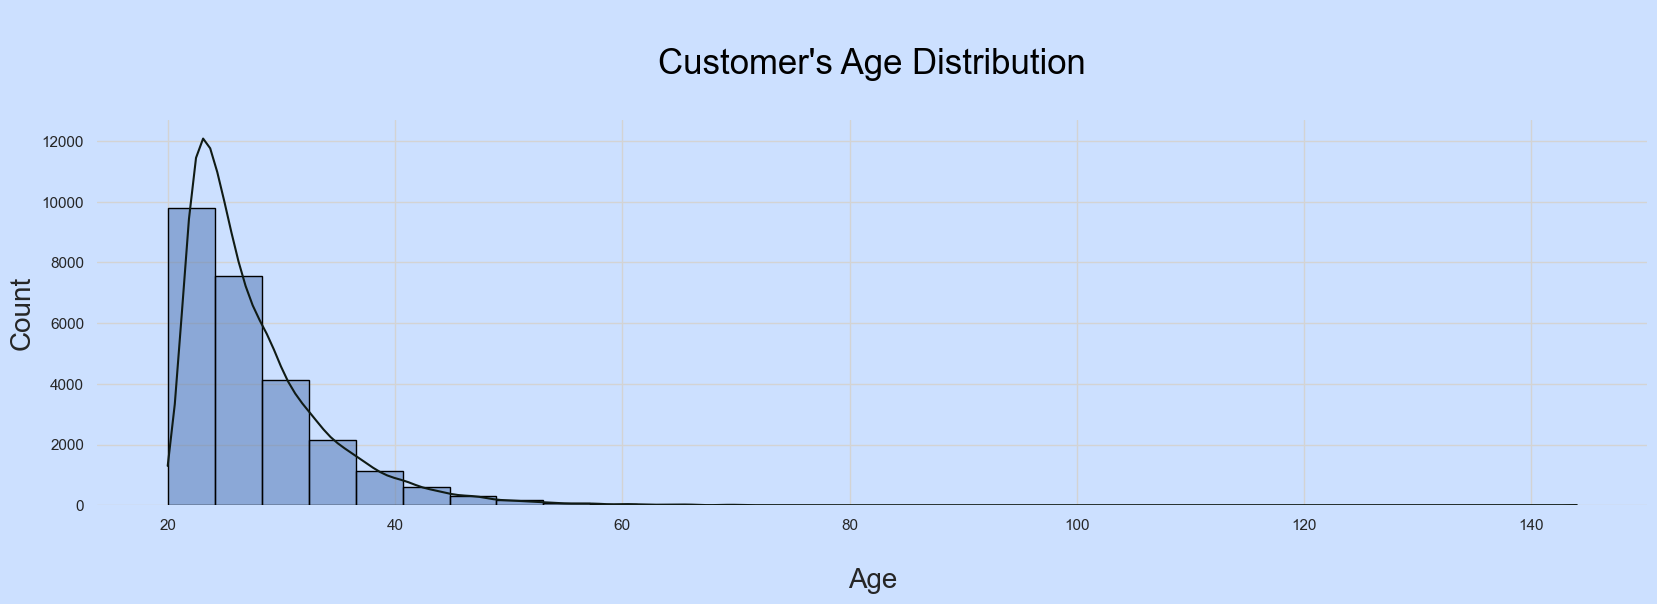

In [25]:
# plot distribution of customer's age
print("Let's have a look on the distribution of customer's age:")

plt.subplots(figsize=(20, 5))

p = sns.histplot(
    x='Age',
    kde=True,
    bins=30,
    fill=True,
    edgecolor='black',
    palette="Set2",
    data=train_df
)

# customize KDE line color
p.axes.lines[0].set_color('#101B15')

# set plot scale
p.axes.set_yscale('linear')

# set title
p.axes.set_title("\nCustomer's Age Distribution\n", fontsize=25)

# axis labels
plt.ylabel("Count", fontsize=20)
plt.xlabel("\nAge", fontsize=20)

# remove unnecessary borders
sns.despine(left=True, bottom=True)

plt.show()

Observation - The variance of the distribution is in the range of 20 to 28....

#### Customer's Loan amount based on their Loan intent

Let's have a look on the distribution of customer's Loan amount:


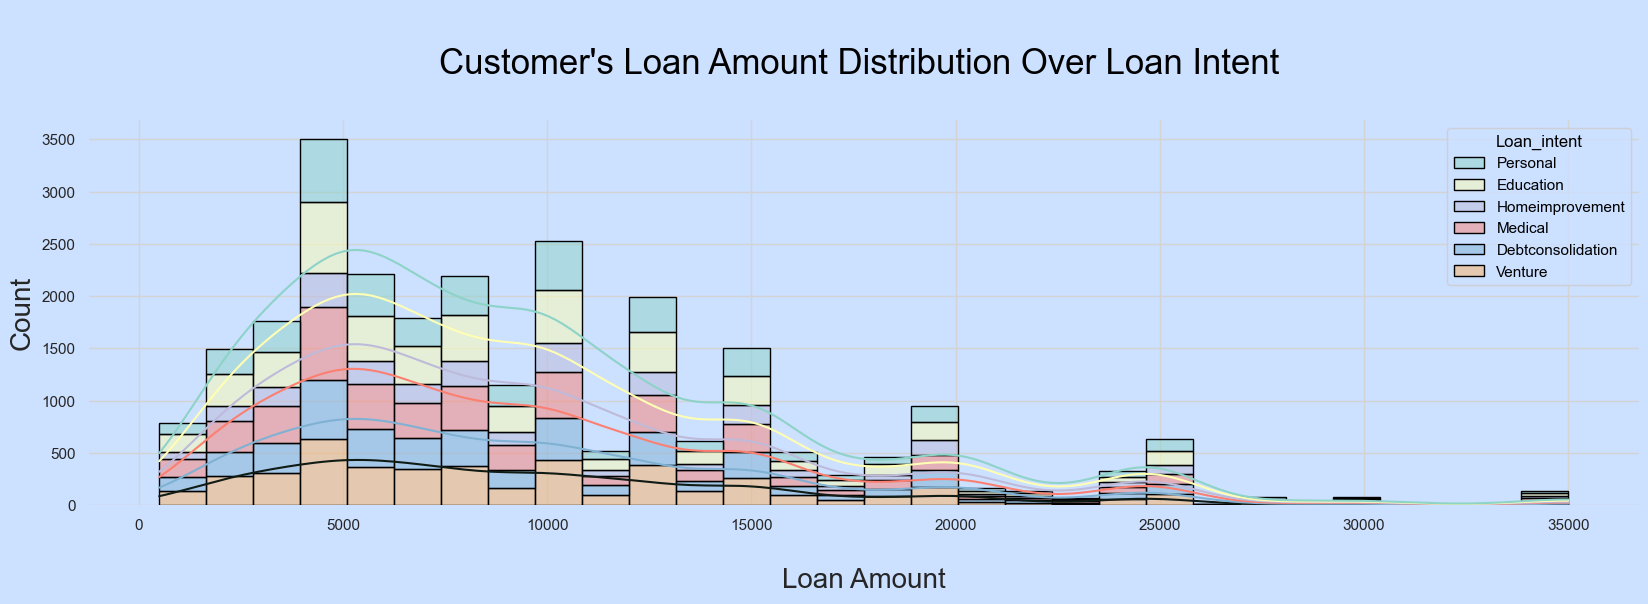

In [26]:
# plot distribution of loan amount with loan intent
print("Let's have a look on the distribution of customer's Loan amount:")

plt.subplots(figsize=(20, 5))

p = sns.histplot(
    x='Loan_amount',
    hue='Loan_intent',
    kde=True,
    multiple='stack',
    bins=30,
    fill=True,
    edgecolor='black',
    palette="Set3",
    data=train_df
)

# customize KDE line color
p.axes.lines[0].set_color('#101B15')

# set scale
p.axes.set_yscale('linear')

# set title
p.axes.set_title("\nCustomer's Loan Amount Distribution Over Loan Intent \n", fontsize=25)

# axis labels
plt.ylabel("Count", fontsize=20)
plt.xlabel("\nLoan Amount", fontsize=20)

# remove extra borders
sns.despine(left=True, bottom=True)

plt.show()

Observation - Most loans are taken in the mid-range amounts, mainly for personal and education purposes

#### Countplot of Loan Intent column

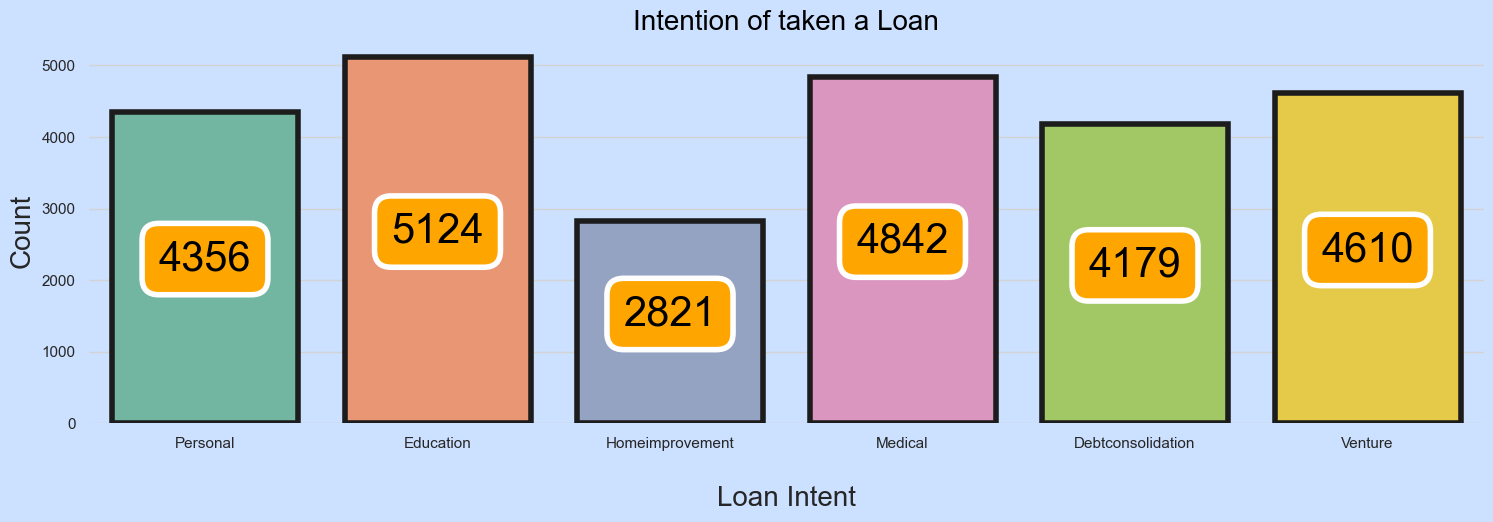

In [27]:
# plot count of loan intent categories
plt.subplots(figsize=(18, 5))

p = sns.countplot(
    x=train_df['Loan_intent'],
    palette="Set2",
    edgecolor="#1c1c1c",
    linewidth=4
)

# set title and labels
p.axes.set_title("Intention of taken a Loan", color="black", fontsize=20)
p.axes.set_ylabel("Count", fontsize=20)
p.axes.set_xlabel("\nLoan Intent", fontsize=20)

# keep x-axis labels horizontal
p.axes.set_xticklabels(p.get_xticklabels(), rotation=0)

# add value labels on bars
for container in p.containers:
    p.bar_label(
        container,
        label_type="center",
        padding=6,
        size=30,
        color="black",
        rotation=0,
        bbox={
            "boxstyle": "round",
            "pad": 0.4,
            "facecolor": "orange",
            "edgecolor": "white",
            "linewidth": 4,
            "alpha": 1
        }
    )

# remove extra borders
sns.despine(left=True, bottom=True)

plt.show()

#### Pie plot of Home ownership column

Let's have a look on the Home_ownership :


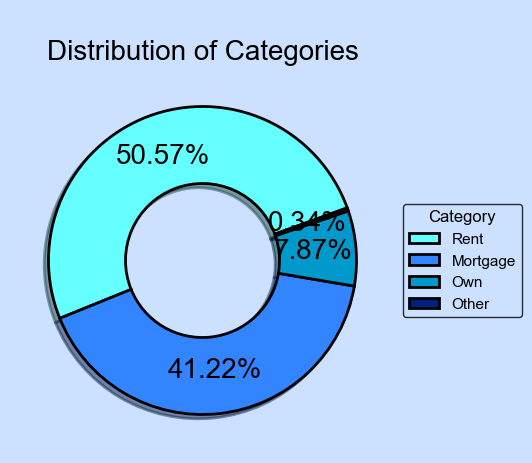

In [28]:
# plot home ownership distribution using pie chart
print("Let's have a look on the Home_ownership :")

plt.subplots(figsize=(20, 5))

labels = "Rent", "Mortgage", "Own", "Other"
size = 0.5

# pie chart of home ownership categories
wedges, texts, autotexts = plt.pie(
    [
        train_df['Home_ownership'].value_counts().iloc[0],
        train_df['Home_ownership'].value_counts().iloc[1],
        train_df['Home_ownership'].value_counts().iloc[2],
        train_df['Home_ownership'].value_counts().iloc[3]
    ],
    autopct="%.2f%%",
    textprops=dict(size=20, color="black"),
    radius=1,
    explode=(0, 0, 0, 0),
    pctdistance=0.72,
    colors=["#66ffff", "#3385ff", "#0099cc", "#002080"],
    shadow=True,
    wedgeprops=dict(width=size, edgecolor="black", linewidth=2),
    startangle=20
)

# add legend
plt.legend(
    wedges,
    labels,
    title="Category",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    edgecolor="black"
)

# set title
plt.title("\nDistribution of Categories", fontsize=20)

plt.show()

#### Countplot of Loan Status column

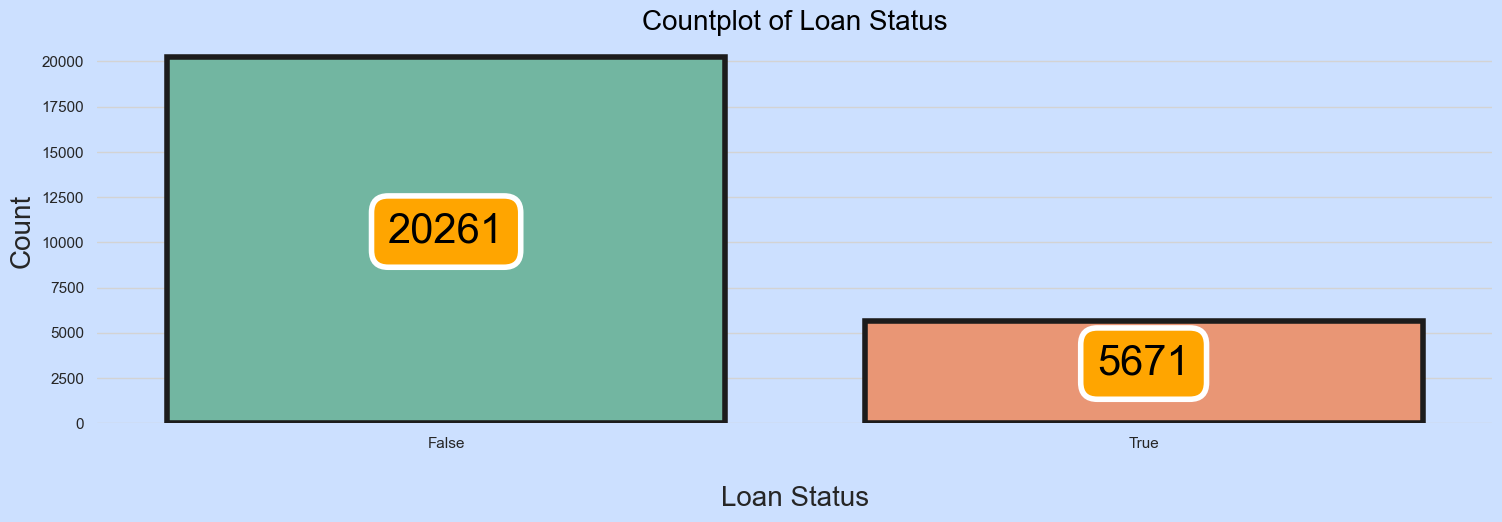

In [29]:
# plot count of loan status
plt.subplots(figsize=(18, 5))

p = sns.countplot(
    x=train_df['Loan_status'],
    palette="Set2",
    edgecolor="#1c1c1c",
    linewidth=4
)

# set title and axis labels
p.axes.set_title("Countplot of Loan Status", color="black", fontsize=20)
p.axes.set_ylabel("Count", fontsize=20)
p.axes.set_xlabel("\nLoan Status", fontsize=20)

# keep x-axis labels horizontal
p.axes.set_xticklabels(p.get_xticklabels(), rotation=0)

# add value labels on bars
for container in p.containers:
    p.bar_label(
        container,
        label_type="center",
        padding=6,
        size=30,
        color="black",
        rotation=0,
        bbox={
            "boxstyle": "round",
            "pad": 0.4,
            "facecolor": "orange",
            "edgecolor": "white",
            "linewidth": 4,
            "alpha": 1
        }
    )

# remove extra borders
sns.despine(left=True, bottom=True)

plt.show()

## Bivariate Analysis


#### Correlation heatmap of numerical features

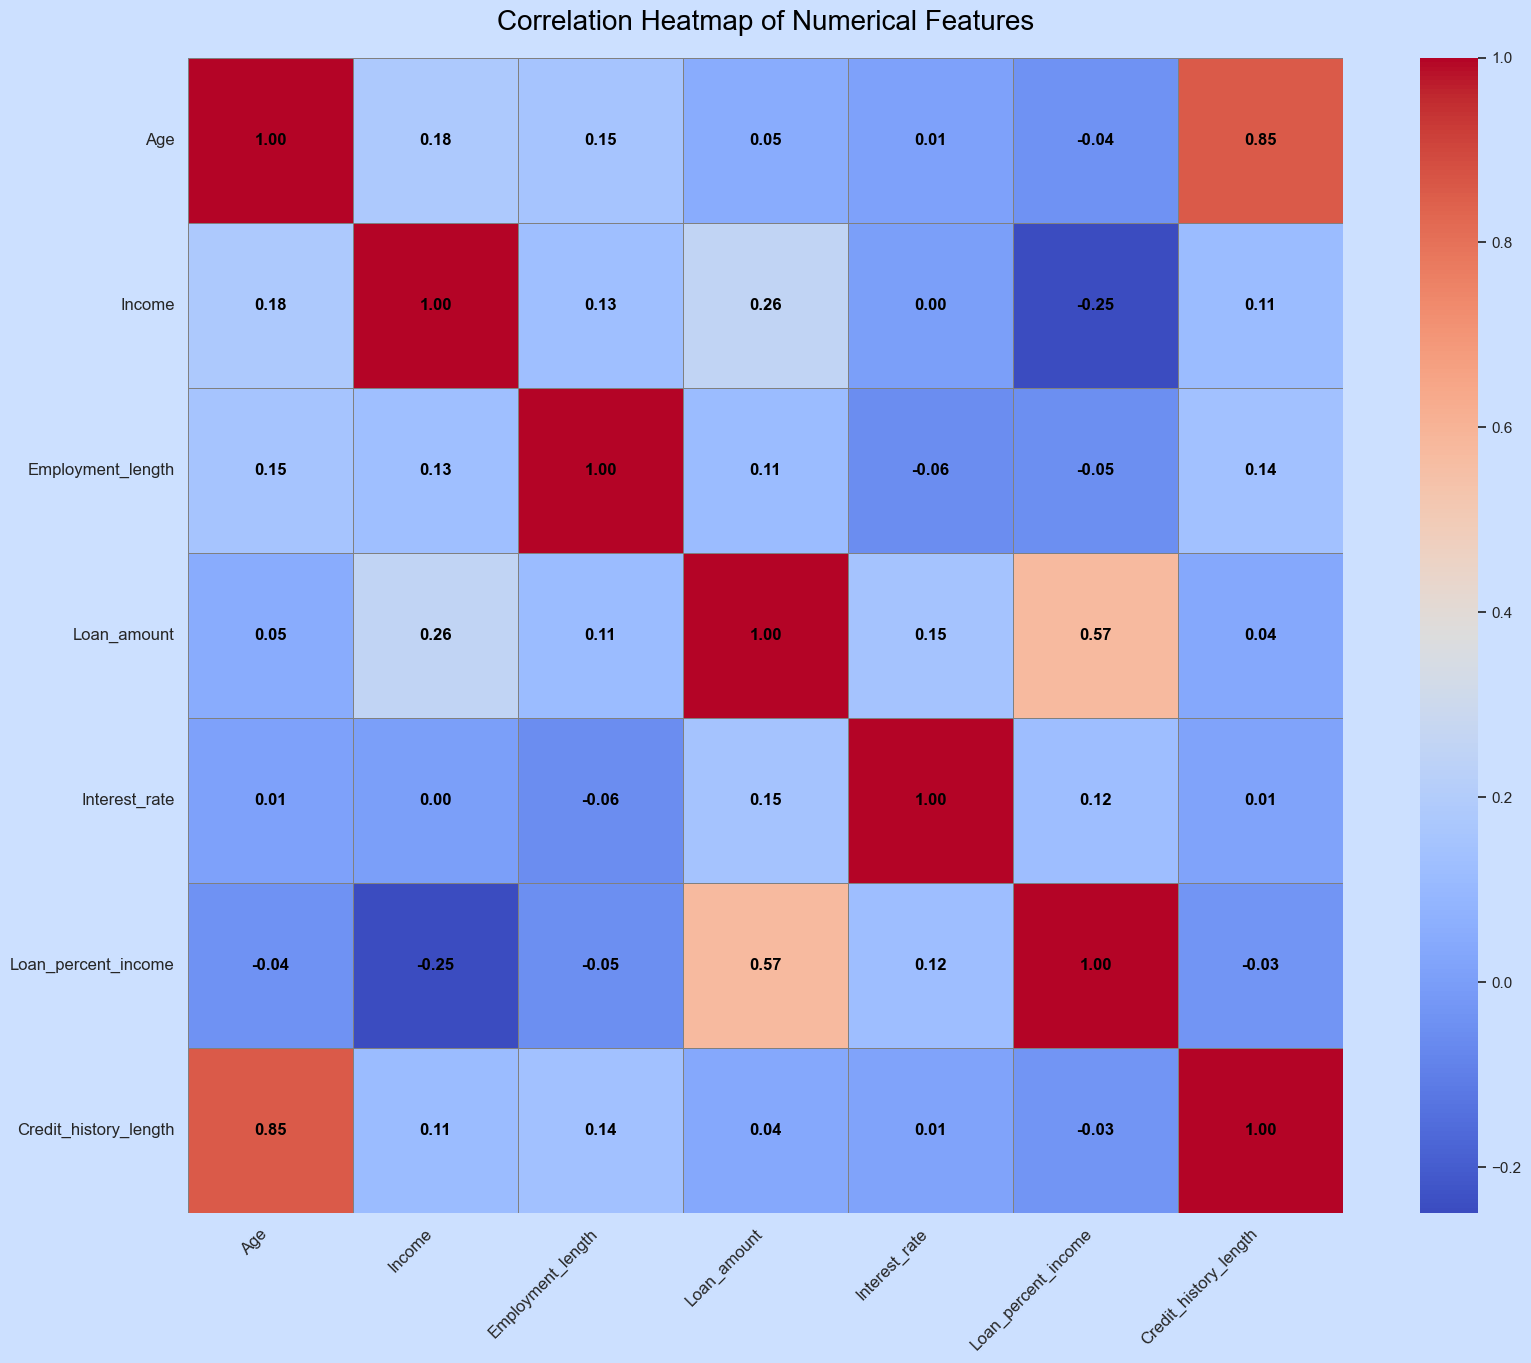

In [30]:
# correlation heatmap of numerical features
plt.subplots(figsize=(20, 15))

# compute correlation matrix
corr = train_df.select_dtypes(include=['int', 'float']).corr()

# plot heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 12, "weight": "bold", "color": "black"},
    square=True
)

# format axis labels
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# title
plt.title("Correlation Heatmap of Numerical Features", fontsize=20, pad=20)

plt.show()

Obervastion -
You can see Age is highly correlated with Credit history length means if high Age is reason of rising the usage of credit....
here between income and loan amount correlation is positive means if more highly income person take high loans....
Other things like loan_percent_income, which relates to income, or loan_percent_income, which relates to the loan amount, are all due to (Loan_Amount/Income).

#### Bar plot of internal credit rating column

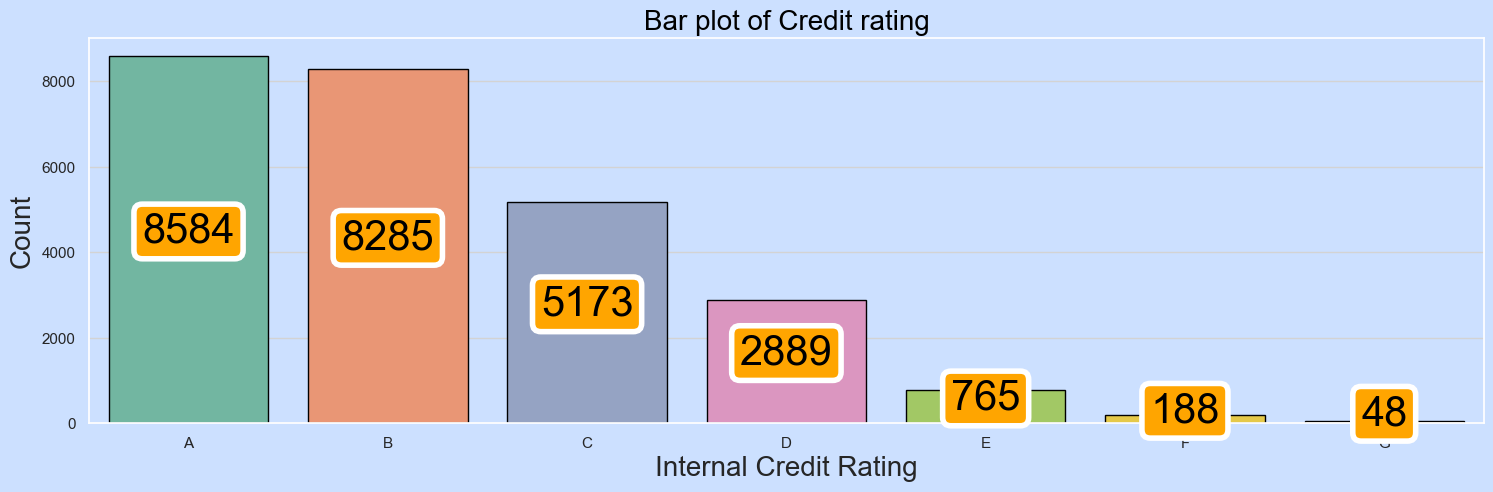

In [31]:
# bar plot of internal credit rating
plt.subplots(figsize=(18, 5))

p = sns.barplot(
    x=train_df['internal_credit_rating'].value_counts().keys(),
    y=train_df['internal_credit_rating'].value_counts(),
    palette="Set2",
    edgecolor="#000000"
)

# set title and labels
p.axes.set_title("Bar plot of Credit rating", fontsize=20)
p.axes.set_ylabel("Count", fontsize=20)
p.axes.set_xlabel("Internal Credit Rating", fontsize=20)

# add value labels on bars
for container in p.containers:
    p.bar_label(
        container,
        label_type="center",
        padding=6,
        size=30,
        color="black",
        rotation=0,
        bbox={
            "boxstyle": "round",
            "pad": 0.2,
            "facecolor": "orange",
            "edgecolor": "white",
            "linewidth": 4,
            "alpha": 1
        }
    )

plt.show()

#### Scatter plot of Income and Loan Amount

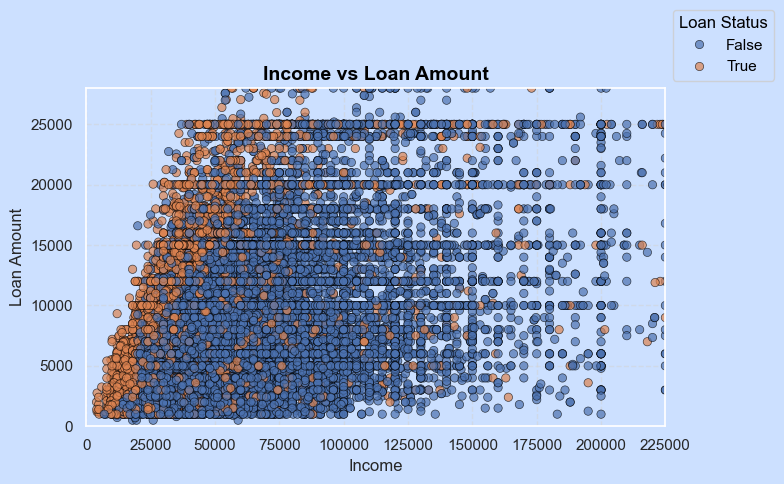

In [32]:
# scatter plot between income and income with loan amount

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Income',
    y='Loan_amount',
    hue='Loan_status',
    data=train_df,
    alpha=0.7,
    edgecolor='black'
)

# title and labels
plt.title("Income vs Loan Amount", fontsize=14, weight='bold')
plt.xlabel("Income")
plt.ylabel("Loan Amount")

# limit extreme values for better visibility
plt.xlim(0, train_df['Income'].quantile(0.99))
plt.ylim(0, train_df['Loan_amount'].quantile(0.99))

# legend placement
plt.legend(title="Loan Status", bbox_to_anchor=(1, 1))

# grid styling
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Observation - As you can see clearly As income increases, the loan amount increases.
- Low Income with High loan amount has mostly default the loan and low income person who taken low amount of loan also default
- for almost all the low level income and low loan amount of people takes loan easily

#### Boxplot of numerical features based on Loan status column

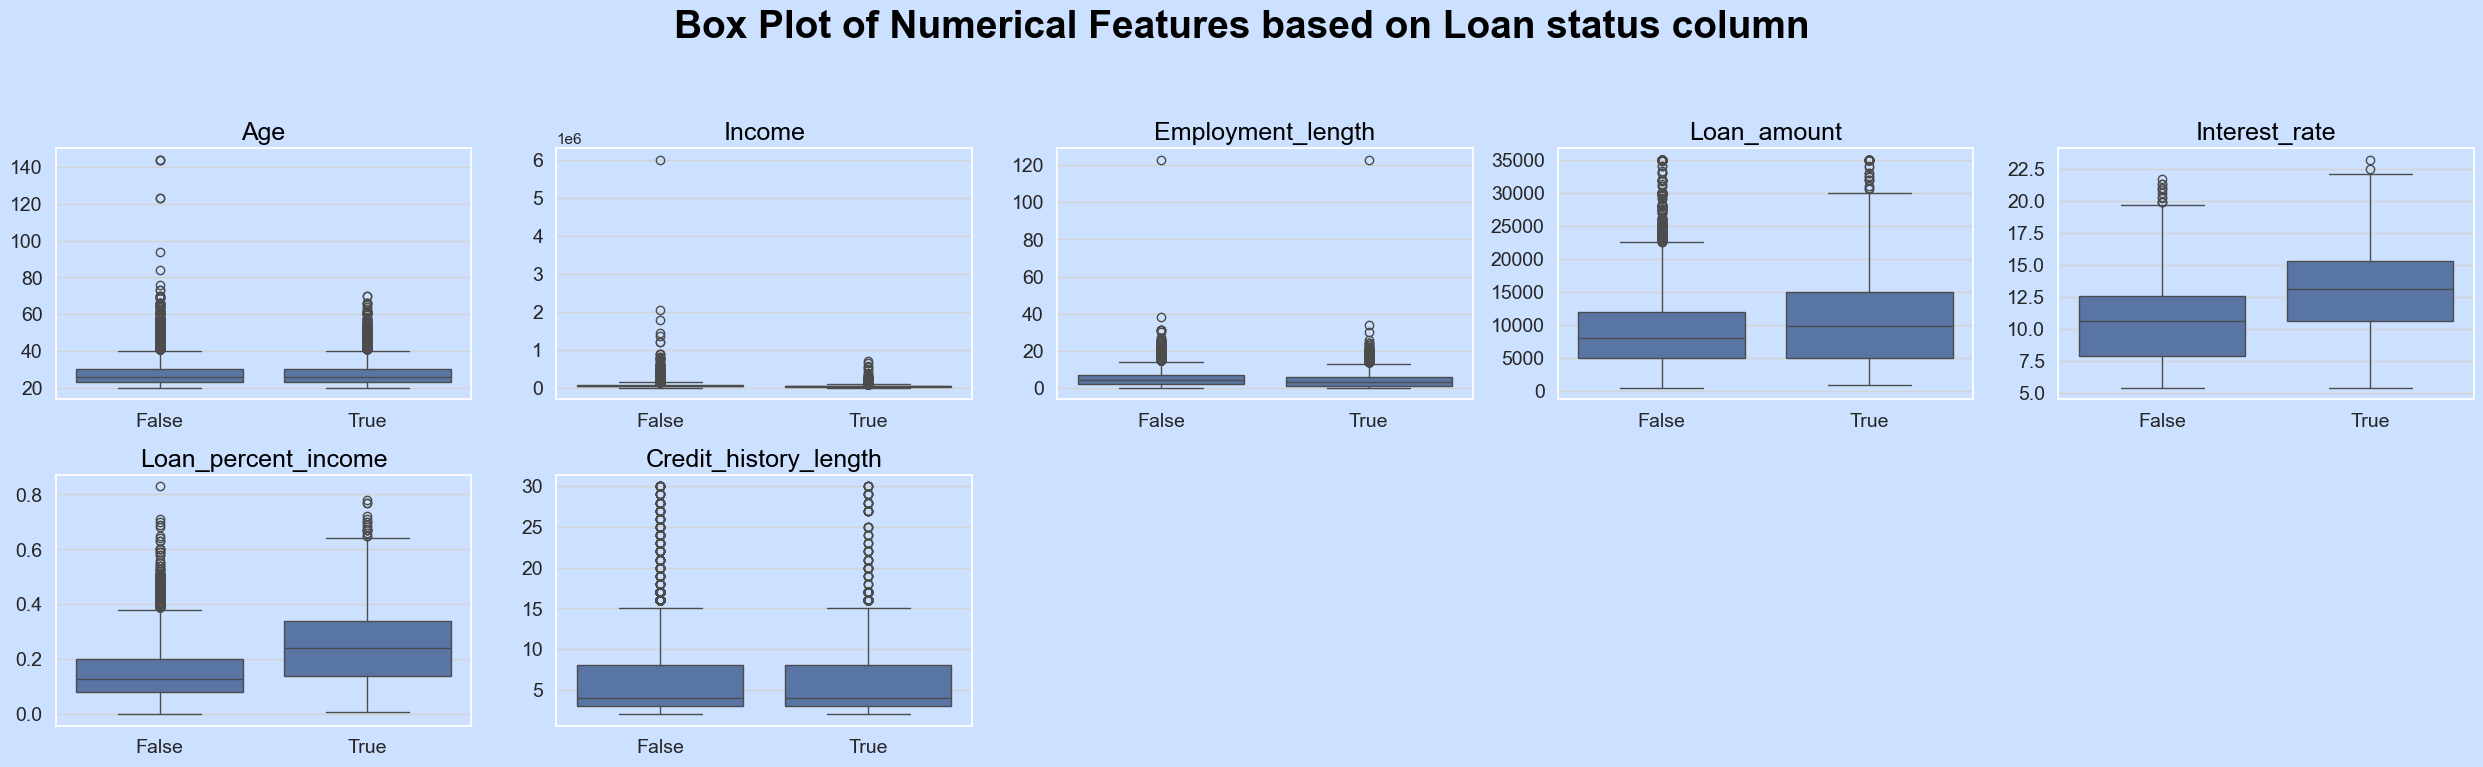

In [33]:
# boxplots of numerical features grouped by loan status
plt.figure(figsize=(25, 20))  # large enough for 6x5 grid

# overall title
plt.suptitle(
    'Box Plot of Numerical Features based on Loan status column',
    fontsize=28,
    fontweight='bold',
    y=1.02
)

# iterate over numerical columns
for i, col_name in enumerate(train_df.select_dtypes(include=['float', 'int64']), 1):
    plt.subplot(6, 5, i)
    sns.boxplot(x='Loan_status', y=col_name, data=train_df)
    plt.title(f'{col_name}', fontsize=18)
    plt.xlabel('')
    plt.xticks(fontsize=14)
    plt.ylabel('')
    plt.yticks(fontsize=14)

# adjust layout
plt.tight_layout()
plt.show()

Observation - In all columns outliers is there, but it's legitmate and very dense and that's we unable to remove for better model training and evaluation

#### Additional realtionships between columns

In [34]:
print("Credit rating group wise Average Interest rate....")

train_df.groupby('internal_credit_rating')['Interest_rate'].mean()

Credit rating group wise Average Interest rate....


internal_credit_rating
A     7.668524
B    11.011446
C    13.233327
D    15.013290
E    16.534970
F    17.622553
G    19.559625
Name: Interest_rate, dtype: float64

In [35]:
print("Credit rating group wise Loan status....")

pd.crosstab(train_df['internal_credit_rating'], train_df['Loan_status'])

Credit rating group wise Loan status....


Loan_status,False,True
internal_credit_rating,,
A,7727,857
B,6931,1354
C,4092,1081
D,1184,1705
E,274,491
F,52,136
G,1,47


Observation - Lower credit rating → higher interest rate, meaning pricing is risk-based (risk ↑ ⇒ interest ↑).

- Lower ratings (D–G) have most defaults that's why all of this is riskier persons to get the loan easily

<Axes: xlabel='Loan_intent', ylabel='Home_ownership'>

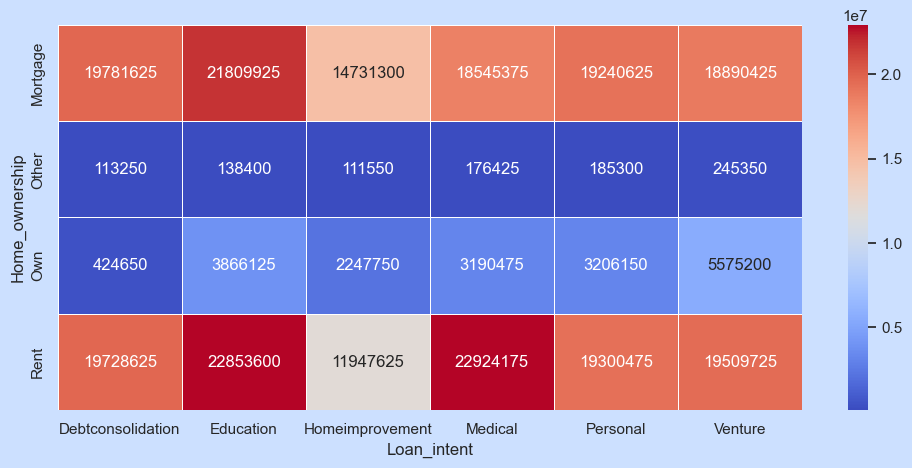

In [36]:
# pivot table: total loan amount by home ownership and loan intent

plt.figure(figsize=(12,5))
sns.heatmap(
    train_df.pivot_table(
        index='Home_ownership',
        columns='Loan_intent',
        values='Loan_amount',
        aggfunc='sum'
    ),
    cmap="coolwarm",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

<Axes: xlabel='internal_credit_rating', ylabel='Loan_intent'>

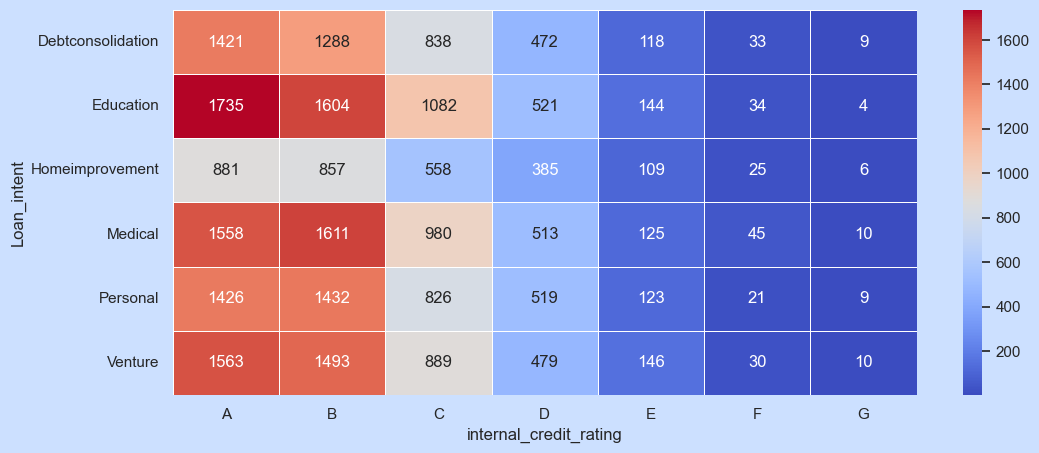

In [37]:
# pivot table: count of records by loan intent and credit rating
plt.figure(figsize=(12,5))

sns.heatmap(
    train_df.pivot_table(
        index='Loan_intent',
        columns='internal_credit_rating',
        aggfunc='size'   # counts
    ),
    cmap="coolwarm",
    annot=True,        # show numbers
    fmt=".0f",         # no decimals
    linewidths=0.5
)

Observation - People with rent or mortgage take higher loans because they rely more on external financing for housing and expenses

Observation - credit rating group wise top group:

A - Education (highest in Education, lowest in Homeimprovement)

B - Education & Medical (highest in Education, lowest in Homeimprovement)

C - Education (highest in Education, lowest in Homeimprovement)

D - Medical & Education (highest in Medical, lowest in Homeimprovement)

E - Education (highest in Education, lowest in Homeimprovement)

F - Medical (highest in Medical, lowest in Personal)

G - Venture & Medical (highest in Venture, lowest in Education/Homeimprovement)

Observation - Most of the customer takes loan on Educational and Medical, Lowest loan category is Home Improvement

In [38]:
train_df.head()

,Age,Income,Home_ownership,Employment_length,Loan_intent,internal_credit_rating,Loan_amount,Interest_rate,Loan_percent_income,Default,Credit_history_length,Loan_status
0,23.0,75800.0,Rent,0.0,Personal,A,7000.0,6.54,0.09,N,2.0,False
1,25.0,61959.0,Rent,9.0,Education,C,25000.0,12.73,0.40,Y,4.0,True
2,31.0,53088.0,Rent,0.0,Personal,A,6000.0,6.54,0.11,N,9.0,False
3,27.0,228000.0,Mortgage,12.0,Homeimprovement,A,6000.0,7.14,0.03,N,6.0,False
4,29.0,54000.0,Rent,0.0,Personal,D,10000.0,14.96,0.19,N,9.0,True
